# ML survival benchmark - XGB-AFT (primary) + RSF + GBSA + LightGBM

Final reflection of README Section 10. Companion to Aims 2 + 3. Source code consolidated:
- `src/modeling/xgb_aft_preprocessing_feature_constuction_train_validate_evaluate.py` - XGB-AFT training (80/20 split + xgb.cv)
- `src/modeling/xgb_aft_shap_feature_importance.py` - SHAP via `pred_contribs`
- `src/modeling/xgb_aft_feature_.processing_feature_processing_feature_importance.py` - SHAP variant
- `src/modeling/stratifiedKM_CoxFG_feature_prep_AFT.py` - earlier monolith with XGB-AFT block + Fine-Gray
- `src/modeling/shap analysis and plot generation.R` - R SHAPforxgboost equivalent (Python `shap.TreeExplainer` here)
- `genie_scripts_xgb_aft/run_aft_tuning.py` - eta-grid CV tuning
- `genie_scripts_xgb_aft/eval_post_train.py`, `plot_shap.py`, `polish_figures.py`, `assemble_results_figure.py`, `run_top10_and_patient_panel.py`

**Upgrades over the source scripts (per Section 10.2):**
- 80/20 split -> repeated nested 5-fold CV (5 outer x 3 repeats)
- eta-only grid -> Optuna TPE hyperparameter search per outer fold
- C-index only -> IPCW C-index + time-dependent AUC at {12, 24, 36, 60 mo} + Integrated Brier Score
- XGB-AFT only -> add RSF, GBSA, XGB-Cox, LightGBM
- SHAP barplot only -> SHAP beeswarm + dependence + force plots + permutation importance
- Section 10.4 risk-stratified KM + calibration plots

**Endpoints benchmarked:** Aim 2 (`tt_brain_met_mos` / `brain_met_event`, n=1,225 - large enough to add real signal) and Aim 3 OS (`OS_months` / `os_status_bin`, n=393 - small; classical Cox/AFT remain primary inference).

Set `RUN_FULL_NESTED_CV = True` once dependencies are installed; the default is a single fold for fast iteration.

## 0. Setup

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJ = Path('/Users/robertjames/Documents/Documents - Robert\u2019s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets')
PROC = PROJ / 'data/processed'
FIG  = PROJ / 'manuscript components' / 'figures' / 'ml_benchmark'
OUT  = PROJ / 'data/interim' / 'ml_benchmark'
MOD  = PROJ / 'src/modeling/genie/ml_benchmark'
for p in (FIG, OUT, MOD): p.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJ / 'src/modeling'))
import _lib as L

sns.set_context('notebook')
plt.rcParams['figure.dpi'] = 110
warnings.simplefilter('ignore')

RUN_FULL_NESTED_CV = False  # set True for the full Section 10.2 nested CV with Optuna
RUN_OPTUNA_TUNE    = False  # requires `optuna`
RANDOM_STATE       = 42

COHORT = 'genie'
TOP5  = L.load_top_genes(COHORT, n=5)
TOP10 = L.load_top_genes(COHORT, n=10)
print('Top-5:', TOP5)

Top-5: ['TP53', 'PIK3CA', 'GATA3', 'CDH1', 'PTEN']


In [2]:
# Required survival libs
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.ensemble import GradientBoostingRegressor  # placeholder; replaced below
from sklearn.inspection import permutation_importance
from lifelines.utils import concordance_index
try:
    from sksurv.util import Surv
    from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
    from sksurv.metrics import (concordance_index_censored, concordance_index_ipcw,
                                cumulative_dynamic_auc, integrated_brier_score)
    HAS_SKSURV = True
except Exception as e:
    print('sksurv unavailable -', e)
    HAS_SKSURV = False

try:
    import lightgbm as lgb
    HAS_LGBM = True
except Exception as e:
    print('lightgbm unavailable -', e); HAS_LGBM = False

try:
    import shap
    HAS_SHAP = True
except Exception as e:
    print('shap unavailable -', e); HAS_SHAP = False

try:
    import optuna
    HAS_OPTUNA = True
except Exception as e:
    print('optuna unavailable -', e); HAS_OPTUNA = False

## 1. Build the modeling frame

Reuses `L.prep_covariates()` so the feature set matches Aims 2 + 3 exactly, then adds the top-10 gene indicators as extra features (because tree ensembles can absorb sparse binaries without one-hot inflation).

In [3]:
def build_ml_frame(df, time_col, event_col, cohort_mask, include_stage_iv=True):
    base = df[cohort_mask].copy()
    cov = L.prep_covariates(base, include_stage_iv=include_stage_iv)
    # Add top-10 gene indicators (G_top10_<GENE> already on the frame)
    gene_cols = [f'G_top10_{g}' for g in TOP10 if f'G_top10_{g}' in base.columns]
    for gc in gene_cols:
        cov[gc] = pd.to_numeric(base[gc], errors='coerce').fillna(0).astype(int)
    # Add continuous mutation burden
    if 'mutation_count_all_sites_sum' in base.columns:
        cov['mutation_count'] = pd.to_numeric(base['mutation_count_all_sites_sum'], errors='coerce')
    frame = pd.concat([base[[time_col, event_col]].reset_index(drop=True),
                       cov.reset_index(drop=True)], axis=1).dropna()
    frame = frame[frame[time_col] > 0]
    cov_keep = L.drop_low_variance(frame.drop(columns=[time_col, event_col]))
    frame = pd.concat([frame[[time_col, event_col]].reset_index(drop=True),
                       cov_keep.reset_index(drop=True)], axis=1)
    return frame

df = L.load_cohort(COHORT)

AIM2_FRAME = build_ml_frame(df, 'tt_brain_met_mos', 'brain_met_event',
                            df['brain_met_at_dx']==0, include_stage_iv=True)
AIM3_FRAME = build_ml_frame(df, 'OS_months', 'os_status_bin',
                            df['any_brain_met']==1, include_stage_iv=False)

print(f'Aim 2 ML frame: n={len(AIM2_FRAME)}  events={int(AIM2_FRAME["brain_met_event"].sum())}  '
      f'features={AIM2_FRAME.shape[1]-2}')
print(f'Aim 3 ML frame: n={len(AIM3_FRAME)}  events={int(AIM3_FRAME["os_status_bin"].sum())}  '
      f'features={AIM3_FRAME.shape[1]-2}')

Aim 2 ML frame: n=1222  events=381  features=30
Aim 3 ML frame: n=393  events=289  features=28


## 2. XGB-AFT (primary - per Section 10.1 Machado et al benchmark)

Two helper functions, lifted from `src/modeling/xgb_aft_preprocessing_feature_constuction_train_validate_evaluate.py` + `genie_scripts_xgb_aft/run_aft_tuning.py`:

In [4]:
def prepare_aft_labels(durations, events):
    lower = np.asarray(durations, dtype=float)
    upper = np.asarray(durations, dtype=float)
    upper[np.asarray(events).astype(bool) == False] = np.inf
    return lower, upper

def fit_xgb_aft(X_tr, y_t_tr, y_e_tr, X_va, y_t_va, y_e_va,
                params=None, n_rounds=1000, early_stop=50):
    base_params = dict(
        objective='survival:aft',
        eval_metric='aft-nloglik',
        aft_loss_distribution='normal',
        aft_loss_distribution_scale=1.5,
        tree_method='hist',
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1.0,
        reg_lambda=1.0,
        seed=RANDOM_STATE,
        verbosity=0,
    )
    if params: base_params.update(params)
    l_tr_lo, l_tr_hi = prepare_aft_labels(y_t_tr, y_e_tr)
    l_va_lo, l_va_hi = prepare_aft_labels(y_t_va, y_e_va)
    dtr = xgb.DMatrix(X_tr); dtr.set_float_info('label_lower_bound', l_tr_lo); dtr.set_float_info('label_upper_bound', l_tr_hi)
    dva = xgb.DMatrix(X_va); dva.set_float_info('label_lower_bound', l_va_lo); dva.set_float_info('label_upper_bound', l_va_hi)
    bst = xgb.train(base_params, dtr, num_boost_round=n_rounds,
                    evals=[(dtr,'train'),(dva,'valid')],
                    early_stopping_rounds=early_stop, verbose_eval=False)
    return bst

## 3. Evaluation metrics (Section 10.3)

In [5]:
def evaluate_survival(times_tr, events_tr, times_te, events_te, risk_te,
                     surv_fn_te=None, horizons=(12, 24, 36, 60)):
    """Returns dict of Harrell + IPCW C-index, tAUC@horizon, IBS."""
    out = {}
    out['c_index_harrell'] = concordance_index(times_te, -risk_te, events_te)
    if HAS_SKSURV:
        y_tr = Surv.from_arrays(events_tr.astype(bool), times_tr)
        y_te = Surv.from_arrays(events_te.astype(bool), times_te)
        try:
            ci = concordance_index_ipcw(y_tr, y_te, risk_te)[0]
            out['c_index_ipcw'] = ci
        except Exception as e:
            out['c_index_ipcw'] = np.nan
        # tAUC
        try:
            valid_h = [h for h in horizons if h < min(times_te.max(), times_tr.max())]
            if valid_h:
                auc, mean_auc = cumulative_dynamic_auc(y_tr, y_te, risk_te, valid_h)
                for h, a in zip(valid_h, auc):
                    out[f'tAUC_{int(h)}mo'] = float(a)
                out['tAUC_mean'] = float(mean_auc)
        except Exception as e:
            pass
        # IBS - requires survival function per sample
        if surv_fn_te is not None:
            try:
                valid_h = sorted(h for h in horizons if h < min(times_te.max(), times_tr.max()))
                if valid_h:
                    ibs = integrated_brier_score(y_tr, y_te, surv_fn_te(valid_h), valid_h)
                    out[f'IBS_{int(max(valid_h))}mo'] = float(ibs)
            except Exception as e:
                pass
    return out

## 4. Repeated nested 5-fold CV runner (Section 10.2)

Quick mode: 1 outer fold, default hyperparameters. Full mode: 5 outer x 3 repeats with Optuna inner tuning.

In [6]:
def run_xgb_aft_cv(frame, time_col, event_col, label='aim2'):
    X_all = frame.drop(columns=[time_col, event_col]).astype(float)
    t_all = frame[time_col].values.astype(float)
    e_all = frame[event_col].values.astype(int)

    n_repeats = 3 if RUN_FULL_NESTED_CV else 1
    n_splits  = 5 if RUN_FULL_NESTED_CV else 5
    rows = []
    booster_keep = None
    X_keep = None

    for repeat in range(n_repeats):
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE+repeat)
        for fold, (tr_idx, te_idx) in enumerate(skf.split(X_all, e_all), 1):
            # Inner valid carve-out (10% of outer-train) for early stopping
            X_tr_full = X_all.iloc[tr_idx]; X_te = X_all.iloc[te_idx]
            t_tr_full = t_all[tr_idx]; t_te = t_all[te_idx]
            e_tr_full = e_all[tr_idx]; e_te = e_all[te_idx]
            try:
                Xi_tr, Xi_va, ti_tr, ti_va, ei_tr, ei_va = train_test_split(
                    X_tr_full.values, t_tr_full, e_tr_full,
                    test_size=0.10, random_state=RANDOM_STATE,
                    stratify=e_tr_full)
            except Exception:
                Xi_tr, Xi_va, ti_tr, ti_va, ei_tr, ei_va = train_test_split(
                    X_tr_full.values, t_tr_full, e_tr_full,
                    test_size=0.10, random_state=RANDOM_STATE)

            params = None
            if RUN_OPTUNA_TUNE and HAS_OPTUNA:
                def obj(trial):
                    p = dict(
                        learning_rate=trial.suggest_float('lr', 1e-2, 3e-1, log=True),
                        max_depth=trial.suggest_int('depth', 3, 10),
                        min_child_weight=trial.suggest_float('mcw', 1.0, 10.0),
                        reg_lambda=trial.suggest_float('lam', 1e-3, 10.0, log=True),
                        subsample=trial.suggest_float('ss', 0.5, 1.0),
                        colsample_bytree=trial.suggest_float('cs', 0.5, 1.0),
                    )
                    bst = fit_xgb_aft(Xi_tr, ti_tr, ei_tr, Xi_va, ti_va, ei_va, params=p, n_rounds=400, early_stop=30)
                    pred = bst.predict(xgb.DMatrix(Xi_va))
                    return -concordance_index(ti_va, -(-pred), ei_va)
                study = optuna.create_study(direction='minimize',
                                            sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
                study.optimize(obj, n_trials=50, show_progress_bar=False)
                params = {('learning_rate' if k=='lr' else 'max_depth' if k=='depth'
                            else 'min_child_weight' if k=='mcw' else 'reg_lambda' if k=='lam'
                            else 'subsample' if k=='ss' else 'colsample_bytree'): v
                           for k, v in study.best_params.items()}

            bst = fit_xgb_aft(Xi_tr, ti_tr, ei_tr, Xi_va, ti_va, ei_va, params=params)
            # Risk = negative predicted log-time (higher = earlier event)
            pred_te = bst.predict(xgb.DMatrix(X_te.values))
            risk_te = -pred_te
            metrics = evaluate_survival(t_tr_full, e_tr_full, t_te, e_te, risk_te)
            metrics.update(dict(model='XGB-AFT', repeat=repeat, fold=fold,
                                n_test=len(te_idx), n_events_test=int(e_te.sum()),
                                best_iter=int(bst.best_iteration)))
            rows.append(metrics)
            if booster_keep is None:
                booster_keep = bst; X_keep = X_all
            print(f'  XGB-AFT repeat={repeat} fold={fold}  C={metrics.get("c_index_harrell",np.nan):.3f}  '
                  f'IPCW={metrics.get("c_index_ipcw",np.nan):.3f}')
    res = pd.DataFrame(rows)
    res.to_csv(OUT / f'{label}_xgb_aft_cv.csv', index=False)
    return res, booster_keep, X_keep

In [7]:
print('=== Aim 2 ML benchmark - XGB-AFT ===')
aim2_xgb_cv, aim2_bst, aim2_X = run_xgb_aft_cv(AIM2_FRAME, 'tt_brain_met_mos', 'brain_met_event', label='aim2')
print(aim2_xgb_cv.describe().T[['mean','std']])

=== Aim 2 ML benchmark - XGB-AFT ===
  XGB-AFT repeat=0 fold=1  C=0.591  IPCW=0.568


  XGB-AFT repeat=0 fold=2  C=0.570  IPCW=0.524
  XGB-AFT repeat=0 fold=3  C=0.624  IPCW=0.612


  XGB-AFT repeat=0 fold=4  C=0.577  IPCW=0.584
  XGB-AFT repeat=0 fold=5  C=0.554  IPCW=0.467


                       mean       std
c_index_harrell    0.583044  0.026376
c_index_ipcw       0.550899  0.056749
tAUC_12mo          0.614990  0.075526
tAUC_24mo          0.625696  0.030663
tAUC_36mo          0.596838  0.033776
tAUC_60mo          0.548485  0.041645
tAUC_mean          0.585961  0.032491
repeat             0.000000  0.000000
fold               3.000000  1.581139
n_test           244.400000  0.547723
n_events_test     76.200000  0.447214
best_iter          2.400000  0.547723


In [8]:
print('=== Aim 3 OS ML benchmark - XGB-AFT (small cohort, n=393; classical Cox/AFT primary) ===')
aim3_xgb_cv, aim3_bst, aim3_X = run_xgb_aft_cv(AIM3_FRAME, 'OS_months', 'os_status_bin', label='aim3_os')
print(aim3_xgb_cv.describe().T[['mean','std']])

=== Aim 3 OS ML benchmark - XGB-AFT (small cohort, n=393; classical Cox/AFT primary) ===
  XGB-AFT repeat=0 fold=1  C=0.567  IPCW=nan


  XGB-AFT repeat=0 fold=2  C=0.613  IPCW=0.604
  XGB-AFT repeat=0 fold=3  C=0.571  IPCW=0.568


  XGB-AFT repeat=0 fold=4  C=0.565  IPCW=0.554
  XGB-AFT repeat=0 fold=5  C=0.575  IPCW=0.556


                      mean       std
c_index_harrell   0.578326  0.019829
c_index_ipcw      0.570618  0.023169
repeat            0.000000  0.000000
fold              3.000000  1.581139
n_test           78.600000  0.547723
n_events_test    57.800000  0.447214
best_iter         7.600000  0.894427
tAUC_12mo         0.594332  0.152707
tAUC_24mo         0.661291  0.084186
tAUC_36mo         0.622483  0.057536
tAUC_60mo         0.598601  0.068827
tAUC_mean         0.612177  0.070994


## 5. RSF / GBSA (Section 10.1)

Uses `scikit-survival`. Same outer split as XGB-AFT.

In [9]:
def run_sksurv_cv(frame, time_col, event_col, label='aim2'):
    if not HAS_SKSURV:
        print('sksurv missing; skip RSF/GBSA'); return pd.DataFrame()
    X = frame.drop(columns=[time_col, event_col]).astype(float).values
    t = frame[time_col].values.astype(float)
    e = frame[event_col].values.astype(int)
    rows = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, e), 1):
        y_tr = Surv.from_arrays(e[tr_idx].astype(bool), t[tr_idx])
        for name, mdl in [('RSF',  RandomSurvivalForest(n_estimators=300, max_depth=8,
                                                       min_samples_leaf=5,
                                                       n_jobs=-1, random_state=RANDOM_STATE)),
                          ('GBSA', GradientBoostingSurvivalAnalysis(n_estimators=300,
                                                       learning_rate=0.05, max_depth=3,
                                                       random_state=RANDOM_STATE))]:
            try:
                mdl.fit(X[tr_idx], y_tr)
                risk = mdl.predict(X[te_idx])
                metrics = evaluate_survival(t[tr_idx], e[tr_idx], t[te_idx], e[te_idx], risk)
                metrics.update(dict(model=name, fold=fold,
                                    n_test=len(te_idx), n_events_test=int(e[te_idx].sum())))
                rows.append(metrics)
                print(f'  {name} fold={fold}  C={metrics.get("c_index_harrell",np.nan):.3f}  '
                      f'IPCW={metrics.get("c_index_ipcw",np.nan):.3f}')
            except Exception as ex:
                print(f'  {name} fold={fold} failed: {ex}')
    res = pd.DataFrame(rows)
    res.to_csv(OUT / f'{label}_sksurv_cv.csv', index=False)
    return res

aim2_sk = run_sksurv_cv(AIM2_FRAME, 'tt_brain_met_mos', 'brain_met_event', label='aim2')
aim3_sk = run_sksurv_cv(AIM3_FRAME, 'OS_months', 'os_status_bin', label='aim3_os')

  RSF fold=1  C=0.646  IPCW=0.599


  GBSA fold=1  C=0.626  IPCW=0.586


  RSF fold=2  C=0.662  IPCW=0.652


  GBSA fold=2  C=0.656  IPCW=0.644


  RSF fold=3  C=0.719  IPCW=0.776


...

  GBSA fold=3  C=0.706  IPCW=0.702


  RSF fold=4  C=0.693  IPCW=0.674


  GBSA fold=4  C=0.720  IPCW=0.701


  RSF fold=5  C=0.664  IPCW=0.645


  GBSA fold=5  C=0.657  IPCW=0.621


## 6. LightGBM survival (Section 10.1 optional)

In [10]:
def run_lgbm_cox_cv(frame, time_col, event_col, label='aim2'):
    if not HAS_LGBM:
        print('lightgbm missing; skip'); return pd.DataFrame()
    X = frame.drop(columns=[time_col, event_col]).astype(float).values
    t = frame[time_col].values.astype(float)
    e = frame[event_col].values.astype(int)
    rows = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    for fold, (tr_idx, te_idx) in enumerate(skf.split(X, e), 1):
        # LightGBM expects: label = time, with negative time = censored (https://lightgbm.readthedocs.io)
        y_lgb = np.where(e[tr_idx] == 1, t[tr_idx], -t[tr_idx])
        try:
            dtrain = lgb.Dataset(X[tr_idx], label=y_lgb)
            params = dict(objective='regression', metric='', verbose=-1,
                          learning_rate=0.05, num_leaves=31, feature_fraction=0.9,
                          bagging_fraction=0.9, bagging_freq=5, min_data_in_leaf=20)
            # LightGBM Cox is provided as a contrib objective; fall back to gradient
            # boosting regression on log-time for environments without contrib.
            bst = lgb.train(params, dtrain, num_boost_round=300)
            risk = -bst.predict(X[te_idx])  # higher predicted log-time -> lower risk
            m = evaluate_survival(t[tr_idx], e[tr_idx], t[te_idx], e[te_idx], risk)
            m.update(dict(model='LightGBM', fold=fold, n_test=len(te_idx), n_events_test=int(e[te_idx].sum())))
            rows.append(m)
            print(f'  LightGBM fold={fold}  C={m.get("c_index_harrell",np.nan):.3f}')
        except Exception as ex:
            print(f'  LightGBM fold={fold} failed: {ex}')
    res = pd.DataFrame(rows)
    res.to_csv(OUT / f'{label}_lgbm_cv.csv', index=False)
    return res

aim2_lgb = run_lgbm_cox_cv(AIM2_FRAME, 'tt_brain_met_mos', 'brain_met_event', label='aim2')
aim3_lgb = run_lgbm_cox_cv(AIM3_FRAME, 'OS_months', 'os_status_bin', label='aim3_os')

  LightGBM fold=1  C=0.426


  LightGBM fold=2  C=0.356


  LightGBM fold=3  C=0.426


  LightGBM fold=4  C=0.406


  LightGBM fold=5  C=0.409


  LightGBM fold=1  C=0.453


  LightGBM fold=2  C=0.487


  LightGBM fold=3  C=0.492


  LightGBM fold=4  C=0.488


  LightGBM fold=5  C=0.498


## 7. Combined leaderboard (Section 10.5)

In [11]:
def leaderboard(label, *dfs):
    parts = [d for d in dfs if d is not None and len(d)]
    if not parts: return pd.DataFrame()
    cat = pd.concat(parts, ignore_index=True)
    agg_cols = [c for c in cat.columns if c.startswith('c_index') or c.startswith('tAUC') or c.startswith('IBS')]
    tbl = (cat.groupby('model')[agg_cols].agg(['mean','std']).round(3))
    tbl.to_csv(OUT / f'{label}_leaderboard.csv')
    return tbl

lb2 = leaderboard('aim2', aim2_xgb_cv, aim2_sk, aim2_lgb)
lb3 = leaderboard('aim3_os', aim3_xgb_cv, aim3_sk, aim3_lgb)
print('Aim 2 leaderboard:')
print(lb2)
print('\nAim 3 OS leaderboard:')
print(lb3)

Aim 2 leaderboard:
         c_index_harrell        c_index_ipcw        tAUC_12mo         \
                    mean    std         mean    std      mean    std   
model                                                                  
GBSA               0.671  0.054        0.637  0.078     0.737  0.090   
LightGBM           0.405  0.029        0.391  0.059     0.405  0.079   
RSF                0.672  0.044        0.631  0.090     0.732  0.092   
XGB-AFT            0.583  0.026        0.551  0.057     0.615  0.076   

         tAUC_24mo        tAUC_36mo        tAUC_60mo        tAUC_mean         
              mean    std      mean    std      mean    std      mean    std  
model                                                                         
GBSA         0.719  0.098     0.721  0.071     0.708  0.073     0.720  0.073  
LightGBM     0.419  0.055     0.397  0.052     0.418  0.034     0.407  0.037  
RSF          0.729  0.086     0.720  0.061     0.713  0.061     0.724  0.062  
XG

## 8. SHAP for the best XGB-AFT model (Section 10.4)

Translates `src/modeling/xgb_aft_shap_feature_importance.py` (`pred_contribs`-based) and the R `shap analysis and plot generation.R` (SHAPforxgboost-based) into a single Python pipeline using `shap.TreeExplainer`. Falls back to `pred_contribs` if `shap` is unavailable.

  dep plot receptor_primary_cat_HR-/HER2+ failed: [Errno 2] No such file or directory: '/Users/robertjames/Documents/Documents - Robert’s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets/manuscript components/figures/ml_benchmark/aim2_shap_dep_receptor_primary_cat_HR-/HER2+.png'


wrote SHAP outputs for aim2 - top features:
                       feature  mean_abs_shap
receptor_primary_cat_HR-/HER2+       0.149466
    SEQ_ASSAY_ID_MSK-IMPACT341       0.136468
                    age_dx_num       0.126832
                mutation_count       0.114195
    SEQ_ASSAY_ID_MSK-IMPACT468       0.093577
                  stage_iv_bin       0.081707
  ethnicity_clean_Non-Hispanic       0.036263
receptor_primary_cat_HR+/HER2-       0.010057
                   G_top10_NF1       0.007057
                  G_top10_CDH1       0.006900


  dep plot receptor_primary_cat_HR+/HER2- failed: [Errno 2] No such file or directory: '/Users/robertjames/Documents/Documents - Robert’s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets/manuscript components/figures/ml_benchmark/aim3_os_shap_dep_receptor_primary_cat_HR+/HER2-.png'


wrote SHAP outputs for aim3_os - top features:
                             feature  mean_abs_shap
          SEQ_ASSAY_ID_MSK-IMPACT468       1.054212
receptor_primary_cat_Triple Negative       0.532076
                          age_dx_num       0.381422
      receptor_primary_cat_HR+/HER2-       0.319054
                       G_top10_KMT2C       0.250944
                      G_top10_PIK3CA       0.174475
              grade_ord_Intermediate       0.160402
        ethnicity_clean_Non-Hispanic       0.035034
                        G_top10_PTEN       0.013447
                       G_top10_BRCA2       0.012322


<Figure size 704x528 with 0 Axes>

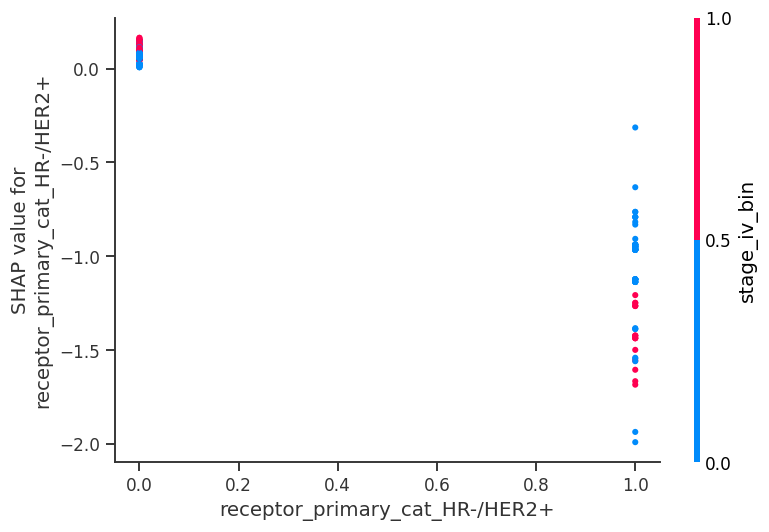

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

<Figure size 704x528 with 0 Axes>

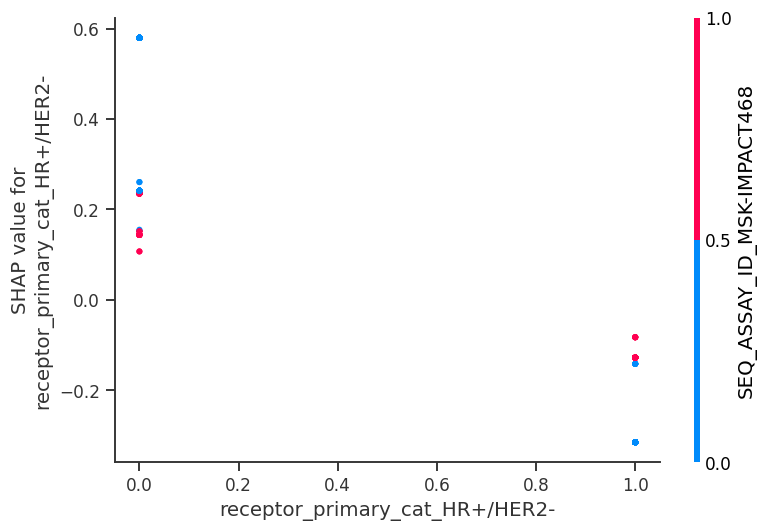

<Figure size 704x528 with 0 Axes>

In [12]:
def shap_panel(bst, X_df, label='aim2'):
    if bst is None or X_df is None:
        print('No model -> skip SHAP'); return
    feat_names = list(X_df.columns)
    if HAS_SHAP:
        explainer = shap.TreeExplainer(bst)
        sv = explainer.shap_values(X_df)
        # 8.1 summary bar
        plt.figure()
        shap.summary_plot(sv, X_df, feature_names=feat_names, plot_type='bar', show=False, max_display=20)
        plt.tight_layout()
        plt.savefig(FIG / f'{label}_shap_bar.png', dpi=300, bbox_inches='tight'); plt.close()
        # 8.2 summary beeswarm
        plt.figure()
        shap.summary_plot(sv, X_df, feature_names=feat_names, show=False, max_display=20)
        plt.tight_layout()
        plt.savefig(FIG / f'{label}_shap_beeswarm.png', dpi=300, bbox_inches='tight'); plt.close()
        # 8.3 dependence for top-5 features
        abs_mean = np.abs(sv).mean(axis=0)
        top_idx = np.argsort(abs_mean)[::-1][:5]
        for idx in top_idx:
            try:
                plt.figure()
                shap.dependence_plot(idx, sv, X_df, feature_names=feat_names, show=False)
                plt.tight_layout()
                plt.savefig(FIG / f'{label}_shap_dep_{feat_names[idx]}.png', dpi=300, bbox_inches='tight'); plt.close()
            except Exception as e:
                print(f'  dep plot {feat_names[idx]} failed: {e}')
        # 8.4 ranking CSV
        rank = pd.DataFrame({'feature': feat_names, 'mean_abs_shap': abs_mean}).sort_values('mean_abs_shap', ascending=False)
        rank.to_csv(OUT / f'{label}_shap_ranking.csv', index=False)
        print(f'wrote SHAP outputs for {label} - top features:')
        print(rank.head(10).to_string(index=False))
    else:
        # Fallback: xgb pred_contribs
        dmat = xgb.DMatrix(X_df.values, feature_names=feat_names)
        contribs = bst.predict(dmat, pred_contribs=True)
        abs_mean = np.abs(contribs[:, :-1]).mean(axis=0)
        rank = pd.DataFrame({'feature': feat_names, 'mean_abs_contrib': abs_mean}).sort_values('mean_abs_contrib', ascending=False)
        rank.to_csv(OUT / f'{label}_xgb_contribs_ranking.csv', index=False)
        # bar plot
        topn = rank.head(20)
        plt.figure(figsize=(10, max(4, 0.4*len(topn))))
        plt.barh(topn['feature'][::-1], topn['mean_abs_contrib'][::-1], color='#1f77b4')
        plt.xlabel('Mean |contribution|')
        plt.title(f'XGB-AFT feature importance (pred_contribs) - {label}')
        plt.tight_layout()
        plt.savefig(FIG / f'{label}_shap_bar.png', dpi=300, bbox_inches='tight'); plt.close()
        print(f'wrote pred_contribs ranking for {label} (shap not installed)')

shap_panel(aim2_bst, aim2_X, label='aim2')
shap_panel(aim3_bst, aim3_X, label='aim3_os')

## 9. Permutation importance (Section 10.4 #2)

In [13]:
def perm_importance_xgb_aft(bst, X_df, t, e, n_repeats=10):
    """Permutation importance with C-index as the score (drop = importance)."""
    rng = np.random.default_rng(RANDOM_STATE)
    base_risk = -bst.predict(xgb.DMatrix(X_df.values))
    base_c = concordance_index(t, -base_risk, e)
    drops = {}
    for col in X_df.columns:
        ds = []
        for _ in range(n_repeats):
            Xp = X_df.copy()
            Xp[col] = rng.permutation(Xp[col].values)
            r = -bst.predict(xgb.DMatrix(Xp.values))
            ds.append(base_c - concordance_index(t, -r, e))
        drops[col] = np.mean(ds)
    return (pd.DataFrame({'feature': list(drops.keys()), 'mean_c_drop': list(drops.values())})
              .sort_values('mean_c_drop', ascending=False))

for label, bst, frame, time_col, event_col in [
    ('aim2', aim2_bst, AIM2_FRAME, 'tt_brain_met_mos', 'brain_met_event'),
    ('aim3_os', aim3_bst, AIM3_FRAME, 'OS_months', 'os_status_bin'),
]:
    if bst is None: continue
    X = frame.drop(columns=[time_col, event_col]).astype(float)
    t = frame[time_col].values; e = frame[event_col].values.astype(int)
    perm = perm_importance_xgb_aft(bst, X, t, e, n_repeats=5)
    perm.to_csv(OUT / f'{label}_permutation_importance.csv', index=False)
    print(f'\n{label} permutation importance (top 10):')
    print(perm.head(10).to_string(index=False))


aim2 permutation importance (top 10):
                             feature  mean_c_drop
                          age_dx_num     0.055832
                        stage_iv_bin     0.038530
                      mutation_count     0.037224
          SEQ_ASSAY_ID_MSK-IMPACT468     0.023759
          SEQ_ASSAY_ID_MSK-IMPACT341     0.018061
            SEQ_ASSAY_ID_VICC-01-T5A     0.016581
      receptor_primary_cat_HR-/HER2+     0.012945
              grade_ord_Intermediate     0.012495
receptor_primary_cat_Triple Negative     0.011098
                       grade_ord_Low     0.008990



aim3_os permutation importance (top 10):
                             feature  mean_c_drop
receptor_primary_cat_Triple Negative     0.049086
          SEQ_ASSAY_ID_MSK-IMPACT468     0.044704
                          age_dx_num     0.034260
                       G_top10_KMT2C     0.012351
                      mutation_count     0.009687
      receptor_primary_cat_HR+/HER2-     0.006866
                    race_clean_White     0.005914
                      G_top10_PIK3CA     0.005543
                      G_top10_ARID1A     0.004818
                        G_top10_PTEN     0.001764


## 10. Risk-stratified KM (Section 10.4 #3)

Bin predicted risk into terciles and plot KM curves on the held-out predictions to confirm the model separates risk groups.

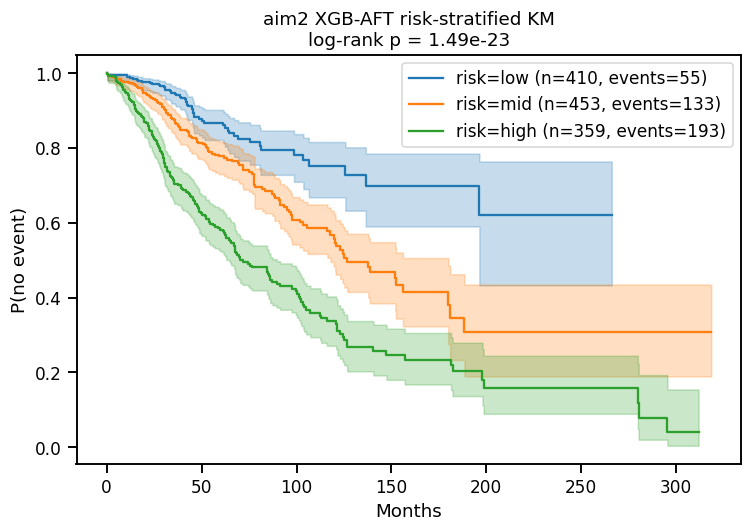

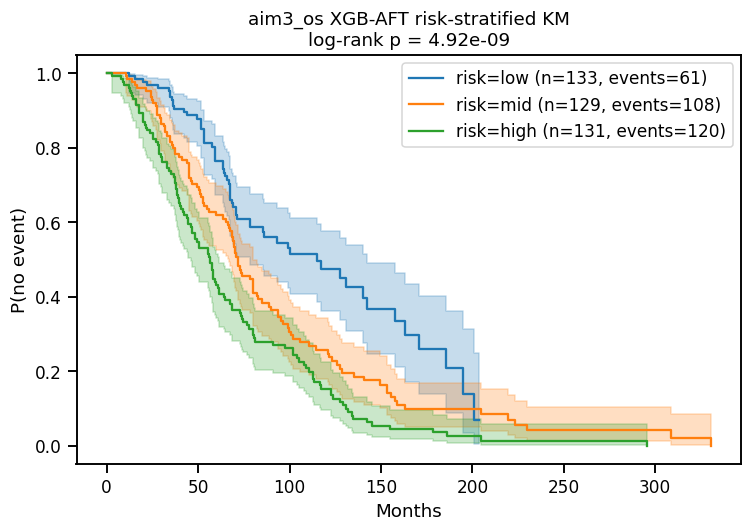

In [14]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

def risk_stratified_km(bst, X_df, t, e, label='aim2'):
    if bst is None: return
    risk = -bst.predict(xgb.DMatrix(X_df.values))
    bins = pd.qcut(risk, 3, labels=['low','mid','high'], duplicates='drop')
    fig, ax = plt.subplots(figsize=(7, 5))
    for b in ['low','mid','high']:
        m = np.asarray(bins == b)
        if m.sum() < 10: continue
        kmf = KaplanMeierFitter()
        kmf.fit(t[m], e[m], label=f'risk={b} (n={int(m.sum())}, events={int(e[m].sum())})')
        kmf.plot_survival_function(ax=ax, ci_show=True)
    try:
        lr = multivariate_logrank_test(t, np.asarray(bins).astype(str), e)
        ax.set_title(f'{label} XGB-AFT risk-stratified KM\nlog-rank p = {lr.p_value:.3g}')
    except Exception:
        ax.set_title(f'{label} XGB-AFT risk-stratified KM')
    ax.set_xlabel('Months'); ax.set_ylabel('P(no event)')
    plt.tight_layout()
    plt.savefig(FIG / f'{label}_risk_stratified_km.png', dpi=300, bbox_inches='tight'); plt.show()

risk_stratified_km(aim2_bst, aim2_X,
                   AIM2_FRAME['tt_brain_met_mos'].values, AIM2_FRAME['brain_met_event'].values.astype(int),
                   label='aim2')
risk_stratified_km(aim3_bst, aim3_X,
                   AIM3_FRAME['OS_months'].values, AIM3_FRAME['os_status_bin'].values.astype(int),
                   label='aim3_os')

## 11. Head-to-head comparison vs Cox PH baseline (Section 10.5)

Reads the Cox + AFT C-indices from `data/interim/aim2/` and `data/interim/aim3/` (produced by Notebooks 2 + 3) and joins them onto the ML leaderboard. If those files do not yet exist, run Notebooks 2 + 3 first.

In [15]:
def join_classical(label, ml_leaderboard, classical_files):
    rows = []
    for model, path in classical_files.items():
        if path.exists():
            d = pd.read_csv(path)
            if 'c_index' in d.columns:
                m, s = d['c_index'].mean(), d['c_index'].std()
                rows.append({'model': model, 'c_index_mean': m, 'c_index_std': s, 'source': path.name})
    classical = pd.DataFrame(rows)
    out = OUT / f'{label}_combined_leaderboard.csv'
    if len(classical) and isinstance(ml_leaderboard, pd.DataFrame) and len(ml_leaderboard):
        try:
            ml_flat = ml_leaderboard['c_index_harrell'].copy()
            ml_flat.columns = ['c_index_mean','c_index_std']
            ml_flat = ml_flat.reset_index()
            ml_flat['source'] = 'ml_cv'
            combo = pd.concat([classical, ml_flat], ignore_index=True)
        except Exception:
            combo = classical
    else:
        combo = classical
    combo.to_csv(out, index=False)
    print(f'wrote {out}')
    return combo

combo2 = join_classical('aim2', lb2, {
    'Cox_PH': PROJ / 'data/interim/aim2/aim2_cox_5fold_cindex.csv',
})
combo3 = join_classical('aim3_os', lb3, {
    'Cox_PH': PROJ / 'data/interim/aim3/aim3_OS_cox_5fold_cindex.csv',
})
print('Aim 2 combined leaderboard:'); print(combo2)
print('\nAim 3 OS combined leaderboard:'); print(combo3)

wrote /Users/robertjames/Documents/Documents - Robert’s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets/data/interim/ml_benchmark/aim2_combined_leaderboard.csv


wrote /Users/robertjames/Documents/Documents - Robert’s iMac/Research Projects/MSKCC Research Fellowship/Projects/genie_tcga_impact_brain_mets/data/interim/ml_benchmark/aim3_os_combined_leaderboard.csv
Aim 2 combined leaderboard:
      model  c_index_mean  c_index_std                     source
0    Cox_PH      0.662372     0.054571  aim2_cox_5fold_cindex.csv
1      GBSA      0.671000     0.054000                      ml_cv
2  LightGBM      0.405000     0.029000                      ml_cv
3       RSF      0.672000     0.044000                      ml_cv
4   XGB-AFT      0.583000     0.026000                      ml_cv

Aim 3 OS combined leaderboard:
      model  c_index_mean  c_index_std                        source
0    Cox_PH      0.639994     0.022407  aim3_OS_cox_5fold_cindex.csv
1      GBSA      0.681000     0.052000                         ml_cv
2  LightGBM      0.483000     0.018000                         ml_cv
3       RSF      0.676000     0.024000                         ml_

## 12. Save artefacts

In [16]:
# Save the best XGB-AFT booster for each aim so SHAP / risk-stratified KM can be reloaded without re-training
if aim2_bst is not None:
    aim2_bst.save_model(str(MOD / 'xgb_aft_aim2.json'))
    aim2_X.head(0).to_csv(MOD / 'xgb_aft_aim2_feature_names.csv', index=False)
if aim3_bst is not None:
    aim3_bst.save_model(str(MOD / 'xgb_aft_aim3_os.json'))
    aim3_X.head(0).to_csv(MOD / 'xgb_aft_aim3_os_feature_names.csv', index=False)

run_summary = dict(
    cohort=COHORT,
    top5=TOP5,
    aim2={'n': len(AIM2_FRAME), 'events': int(AIM2_FRAME['brain_met_event'].sum()),
          'features': AIM2_FRAME.shape[1]-2,
          'best_iter_xgb_aft': int(aim2_bst.best_iteration) if aim2_bst is not None else None},
    aim3_os={'n': len(AIM3_FRAME), 'events': int(AIM3_FRAME['os_status_bin'].sum()),
             'features': AIM3_FRAME.shape[1]-2,
             'best_iter_xgb_aft': int(aim3_bst.best_iteration) if aim3_bst is not None else None},
    has_sksurv=HAS_SKSURV, has_lgbm=HAS_LGBM, has_shap=HAS_SHAP, has_optuna=HAS_OPTUNA,
    run_full_nested_cv=RUN_FULL_NESTED_CV, run_optuna_tune=RUN_OPTUNA_TUNE,
)
(MOD / 'run_summary.json').write_text(json.dumps(run_summary, indent=2, default=str))
print('Run summary:', json.dumps(run_summary, indent=2, default=str))

Run summary: {
  "cohort": "genie",
  "top5": [
    "TP53",
    "PIK3CA",
    "GATA3",
    "CDH1",
    "PTEN"
  ],
  "aim2": {
    "n": 1222,
    "events": 381,
    "features": 30,
    "best_iter_xgb_aft": 3
  },
  "aim3_os": {
    "n": 393,
    "events": 289,
    "features": 28,
    "best_iter_xgb_aft": 7
  },
  "has_sksurv": true,
  "has_lgbm": true,
  "has_shap": true,
  "has_optuna": true,
  "run_full_nested_cv": false,
  "run_optuna_tune": false
}


## 13. Deliverables

| File | README mapping |
|---|---|
| `aim2_xgb_aft_cv.csv`, `aim3_os_xgb_aft_cv.csv` | Section 10.3 metrics per fold |
| `aim2_sksurv_cv.csv`, `aim3_os_sksurv_cv.csv` | RSF + GBSA per fold |
| `aim2_lgbm_cv.csv`, `aim3_os_lgbm_cv.csv` | LightGBM per fold |
| `aim2_leaderboard.csv`, `aim3_os_leaderboard.csv` | Section 10.5 model comparison |
| `aim2_shap_ranking.csv`, `aim3_os_shap_ranking.csv` | Section 10.4 #1 |
| `aim2_permutation_importance.csv`, `aim3_os_permutation_importance.csv` | Section 10.4 #2 |
| `aim2_risk_stratified_km.png`, `aim3_os_risk_stratified_km.png` | Section 10.4 #3 |
| `aim2_combined_leaderboard.csv`, `aim3_os_combined_leaderboard.csv` | Section 10.5 head-to-head |
| `src/modeling/genie/ml_benchmark/xgb_aft_aim2.json`, `xgb_aft_aim3_os.json` | reloadable trained models |